In [4]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import matplotlib.pyplot as plt

In [5]:
X = pd.read_csv(
    "data/outputs/weighted_patient_communication_matrix.csv",
    index_col=0
)

Y = pd.read_csv(
    "data/outputs/validated_patient_programs.csv",
    index_col=0
)

print(X.shape)
print(Y.shape)

(138, 3489)
(138, 10)


In [6]:
common = X.index.intersection(Y.index)

X = X.loc[common]
Y = Y.loc[common]

print(X.shape)
print(Y.shape)

(138, 3489)
(138, 10)


In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(110, 3489)
(28, 3489)


In [8]:
models = {}
results = []

for program in Y.columns:

    rf = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(
        X_train,
        Y_train[program]
    )

    pred = rf.predict(X_test)

    r2 = r2_score(Y_test[program], pred)

    rmse = np.sqrt(
        mean_squared_error(
            Y_test[program],
            pred
        )
    )

    mae = mean_absolute_error(
        Y_test[program],
        pred
    )

    models[program] = rf

    results.append([
        program,
        r2,
        rmse,
        mae
    ])

In [9]:
performance = pd.DataFrame(
    results,
    columns=[
        "Program",
        "R2",
        "RMSE",
        "MAE"
    ]
)

performance.sort_values(
    "R2",
    ascending=False
)

,Program,R2,RMSE,MAE
1,1,0.926639,0.087579,0.056430
0,0,0.900386,0.088743,0.064533
9,9,0.670942,0.178714,0.090174
3,3,0.635320,0.141593,0.093886
5,5,0.631334,0.079428,0.062319
4,4,0.623289,0.069530,0.051275
7,7,0.235661,0.012063,0.007244
8,8,-0.603078,0.081351,0.061616
6,6,-1.304821,0.012442,0.009153
2,2,-6.588902,0.009057,0.005262


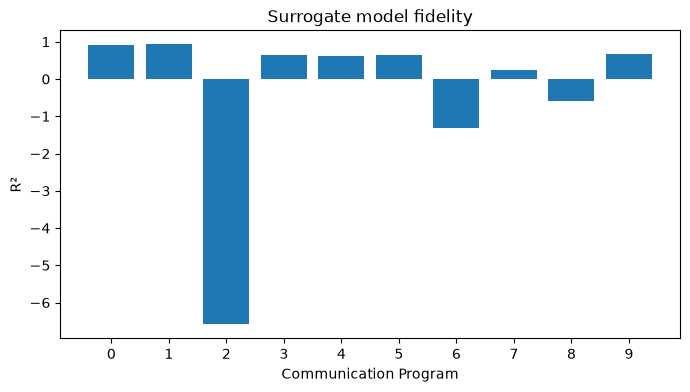

In [10]:
plt.figure(figsize=(8,4))

plt.bar(
    performance["Program"].astype(str),
    performance["R2"]
)

plt.xlabel("Communication Program")
plt.ylabel("R²")

plt.title("Surrogate model fidelity")

plt.show()

In [11]:
os.makedirs("models", exist_ok=True)

for name, model in models.items():
    joblib.dump(
        model,
        f"models/program_{name}.joblib"
    )

performance.to_csv(
    "data/outputs/surrogate_model_performance.csv",
    index=False
)

print("Saved.")

Saved.


In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [13]:
models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    )
}

In [14]:
comparison = []

for model_name, model in models.items():

    r2_scores = []

    for program in Y.columns:

        model.fit(
            X_train,
            Y_train[program]
        )

        pred = model.predict(X_test)

        r2_scores.append(
            r2_score(
                Y_test[program],
                pred
            )
        )

    comparison.append({
        "Model": model_name,
        "Mean_R2": np.mean(r2_scores),
        "Median_R2": np.median(r2_scores),
        "Programs_R2_gt_0.6": np.sum(np.array(r2_scores) > 0.6)
    })

comparison = pd.DataFrame(comparison)

comparison.sort_values(
    "Mean_R2",
    ascending=False
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.029883 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81801
[LightGBM] [Info] Number of data points in the train set: 110, number of used features: 2934
[LightGBM] [Info] Start training from score 0.190544
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

,Model,Mean_R2,Median_R2,Programs_R2_gt_0.6
2,XGBoost,0.497447,0.676346,6
1,Extra Trees,-0.162673,0.534905,5
0,Random Forest,-0.911998,0.601383,5
3,LightGBM,-17.993525,0.502965,5


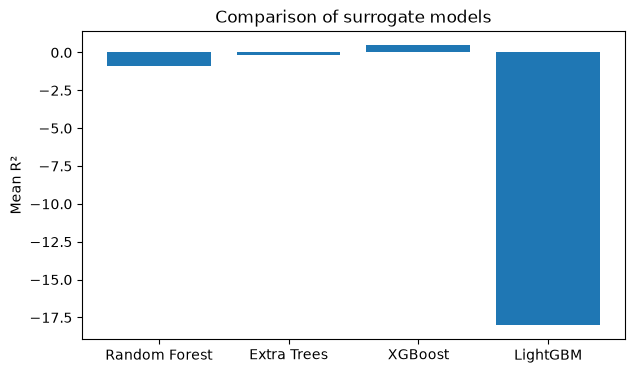

In [15]:
plt.figure(figsize=(7,4))

plt.bar(
    comparison["Model"],
    comparison["Mean_R2"]
)

plt.ylabel("Mean R²")
plt.title("Comparison of surrogate models")

plt.show()

In [16]:
comparison.to_csv(
    "data/outputs/model_comparison.csv",
    index=False
)

comparison

,Model,Mean_R2,Median_R2,Programs_R2_gt_0.6
0,Random Forest,-0.911998,0.601383,5
1,Extra Trees,-0.162673,0.534905,5
2,XGBoost,0.497447,0.676346,6
3,LightGBM,-17.993525,0.502965,5


In [17]:
from sklearn.metrics import r2_score

performance_matrix = pd.DataFrame(index=Y.columns)

for model_name, model in models.items():

    scores = []

    for program in Y.columns:

        model.fit(
            X_train,
            Y_train[program]
        )

        pred = model.predict(X_test)

        scores.append(
            r2_score(
                Y_test[program],
                pred
            )
        )

    performance_matrix[model_name] = scores

performance_matrix

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81801
[LightGBM] [Info] Number of data points in the train set: 110, number of used features: 2934
[LightGBM] [Info] Start training from score 0.190544
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

,Random Forest,Extra Trees,XGBoost,LightGBM
0,0.891544,0.926478,0.908361,0.890298
1,0.924270,0.935386,0.930449,0.928692
2,-10.657052,-4.895728,-0.251697,-146.551808
3,0.619384,0.772136,0.895340,0.625012
4,0.591308,0.667091,0.669184,0.662315
5,0.611459,0.650598,0.683509,0.692182
6,-1.948918,-0.371064,0.024584,-31.323226
7,-0.078319,0.061620,0.057788,-5.824742
8,-0.803443,-0.792456,0.263519,-0.414886
9,0.729784,0.419212,0.793434,0.380918


In [18]:
best_models = pd.DataFrame({
    "Best_Model": performance_matrix.idxmax(axis=1),
    "Best_R2": performance_matrix.max(axis=1)
})

best_models.sort_values(
    "Best_R2",
    ascending=False
)

,Best_Model,Best_R2
1,Extra Trees,0.935386
0,Extra Trees,0.926478
3,XGBoost,0.895340
9,XGBoost,0.793434
5,LightGBM,0.692182
4,XGBoost,0.669184
8,XGBoost,0.263519
7,Extra Trees,0.061620
6,XGBoost,0.024584
2,XGBoost,-0.251697


<Figure size 1000x500 with 0 Axes>

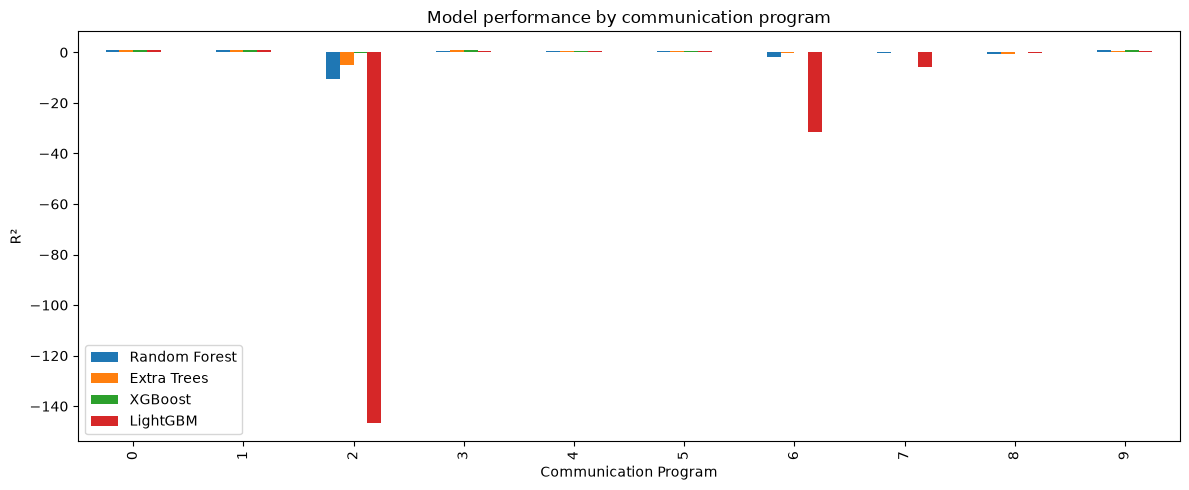

In [19]:
plt.figure(figsize=(10,5))

performance_matrix.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("R²")
plt.xlabel("Communication Program")
plt.title("Model performance by communication program")

plt.tight_layout()
plt.show()

In [20]:
final_models = {}

for program in Y.columns:

    model_name = best_models.loc[program, "Best_Model"]

    model = models[model_name]

    model.fit(
        X,
        Y[program]
    )

    final_models[program] = model

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038290 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 102515
[LightGBM] [Info] Number of data points in the train set: 138, number of used features: 3019
[LightGBM] [Info] Start training from score 0.148809
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [21]:
import joblib
import os

os.makedirs("models", exist_ok=True)

for program, model in final_models.items():

    joblib.dump(
        model,
        f"models/program_{program}_surrogate.pkl"
    )

performance_matrix.to_csv(
    "data/outputs/program_model_comparison.csv"
)

best_models.to_csv(
    "data/outputs/best_surrogate_models.csv"
)

print("Notebook 14 complete.")

Notebook 14 complete.


In [22]:
from sklearn.model_selection import KFold, cross_val_score

In [23]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

kf

KFold(n_splits=5, random_state=42, shuffle=True)

In [24]:
from sklearn.model_selection import RepeatedKFold

cv = RepeatedKFold(
    n_splits=3,
    n_repeats=2,
    random_state=42
)

In [27]:
best_model_table = pd.DataFrame({
    "Program": [
        "0","1","2","3","4","5","6","7","8","9"
    ],
    "Best_Model": [
        "Extra Trees",
        "Extra Trees",
        "XGBoost",
        "XGBoost",
        "XGBoost",
        "LightGBM",
        "XGBoost",
        "Extra Trees",
        "XGBoost",
        "XGBoost"
    ]
})

best_model_table

,Program,Best_Model
0,0,Extra Trees
1,1,Extra Trees
2,2,XGBoost
3,3,XGBoost
4,4,XGBoost
5,5,LightGBM
6,6,XGBoost
7,7,Extra Trees
8,8,XGBoost
9,9,XGBoost


In [30]:
%whos

Variable                Type                     Data/Info
----------------------------------------------------------
ExtraTreesRegressor     ABCMeta                  <class 'sklearn.ensemble.<...>est.ExtraTreesRegressor'>
KFold                   ABCMeta                  <class 'sklearn.model_selection._split.KFold'>
LGBMRegressor           type                     <class 'lightgbm.sklearn.LGBMRegressor'>
RandomForestRegressor   ABCMeta                  <class 'sklearn.ensemble.<...>t.RandomForestRegressor'>
RepeatedKFold           ABCMeta                  <class 'sklearn.model_sel<...>on._split.RepeatedKFold'>
X                       DataFrame                Shape: (138, 3489)
XGBRegressor            type                     <class 'xgboost.sklearn.XGBRegressor'>
X_test                  DataFrame                Shape: (28, 3489)
X_train                 DataFrame                Shape: (110, 3489)
Y                       DataFrame                Shape: (138, 10)
Y_test                  

In [31]:
import shap
import numpy as np
import pandas as pd

In [32]:
shap_values = {}

for program, model in final_models.items():

    print("Running SHAP for program:", program)

    explainer = shap.Explainer(
        model,
        X
    )

    shap_result = explainer(X)

    shap_values[program] = shap_result


print("SHAP completed")

Running SHAP for program: 0
Running SHAP for program: 1
Running SHAP for program: 2
Running SHAP for program: 3
Running SHAP for program: 4
Running SHAP for program: 5
Running SHAP for program: 6
Running SHAP for program: 7
Running SHAP for program: 8
Running SHAP for program: 9
SHAP completed


In [33]:
shap_importance = {}

for program, values in shap_values.items():

    importance = np.abs(
        values.values
    ).mean(axis=0)

    shap_importance[program] = (
        pd.Series(
            importance,
            index=X.columns
        )
        .sort_values(
            ascending=False
        )
    )


shap_df = pd.DataFrame(shap_importance)

shap_df.head()

,0,1,2,3,4,5,6,7,8,9
A2M→LRP1,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
AANAT→MTNR1A,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
AANAT→MTNR1B,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
ACE→AGTR2,0.000002,0.000002,0.0,0.0,0.0,0.0,0.0,0.000002,0.0,0.0
ACE→BDKRB2,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


In [34]:
shap_df.to_csv(
    "data/outputs/shap_feature_importance.csv"
)

print("Saved SHAP importance")

Saved SHAP importance


In [35]:
# Show top SHAP features per communication program

for program in shap_df.columns:

    print("\n======================")
    print("Program:", program)
    print("======================")

    display(
        shap_df[program]
        .sort_values(ascending=False)
        .head(20)
    )


Program: 0


CCL27→CCR10          0.005904
ADM2→ADRB2           0.003795
SLITRK2→PTPRS        0.003696
ADM2→GPR20           0.003219
RLN3→GPR84           0.003021
RLN3→GPR20           0.002858
CCL16→HRH4           0.002604
TNFSF13→TNFRSF13B    0.002510
HDC→HRH3             0.001931
GHRH→TSHR            0.001504
GAST→GPR152          0.001463
DEFB103A→CCR2        0.001135
ICAM4→ITGAL          0.001104
HDC→HRH4             0.001079
LRRC4B→PTPRS         0.001078
GHRH→GPR84           0.001031
IAPP→GPR84           0.001013
APLN→APLNR           0.000993
RLN3→RAMP2           0.000892
ASIP→ATRN            0.000873
Name: 0, dtype: float64


Program: 1


CCL27→CCR10          0.005904
ADM2→ADRB2           0.003795
SLITRK2→PTPRS        0.003696
ADM2→GPR20           0.003219
RLN3→GPR84           0.003021
RLN3→GPR20           0.002858
CCL16→HRH4           0.002604
TNFSF13→TNFRSF13B    0.002510
HDC→HRH3             0.001931
GHRH→TSHR            0.001504
GAST→GPR152          0.001463
DEFB103A→CCR2        0.001135
ICAM4→ITGAL          0.001104
HDC→HRH4             0.001079
LRRC4B→PTPRS         0.001078
GHRH→GPR84           0.001031
IAPP→GPR84           0.001013
APLN→APLNR           0.000993
RLN3→RAMP2           0.000892
ASIP→ATRN            0.000873
Name: 1, dtype: float64


Program: 2


...

CCL27→CCR10          0.005904
ADM2→ADRB2           0.003795
SLITRK2→PTPRS        0.003696
ADM2→GPR20           0.003219
RLN3→GPR84           0.003021
RLN3→GPR20           0.002858
CCL16→HRH4           0.002604
TNFSF13→TNFRSF13B    0.002510
HDC→HRH3             0.001931
GHRH→TSHR            0.001504
GAST→GPR152          0.001463
DEFB103A→CCR2        0.001135
ICAM4→ITGAL          0.001104
HDC→HRH4             0.001079
LRRC4B→PTPRS         0.001078
GHRH→GPR84           0.001031
IAPP→GPR84           0.001013
APLN→APLNR           0.000993
RLN3→RAMP2           0.000892
ASIP→ATRN            0.000873
Name: 7, dtype: float64


Program: 8


MDK→LRP2        0.042852
PSEN1→NCSTN     0.022853
APOE→LSR        0.013753
LGALS9→PTPRC    0.009580
TCN2→LRP2       0.008467
ANOS1→SDC2      0.006600
ADAM23→ITGA4    0.006577
MDK→SORL1       0.006367
C3→C3AR1        0.006360
ZP3→EGFR        0.005573
LRPAP1→LRP2     0.004725
C4BPA→BMPR2     0.004149
MXRA5→ILDR1     0.003669
BTC→ERBB3       0.003656
COL9A1→SDC1     0.003526
LRPAP1→SORL1    0.002992
EFNA5→EPHB1     0.002990
ZG16B→TLR6      0.002907
NTN4→UNC5A      0.002489
CFP→NCR1        0.002211
Name: 8, dtype: float64


Program: 9


MDK→LRP2        0.042852
PSEN1→NCSTN     0.022853
APOE→LSR        0.013753
LGALS9→PTPRC    0.009580
TCN2→LRP2       0.008467
ANOS1→SDC2      0.006600
ADAM23→ITGA4    0.006577
MDK→SORL1       0.006367
C3→C3AR1        0.006360
ZP3→EGFR        0.005573
LRPAP1→LRP2     0.004725
C4BPA→BMPR2     0.004149
MXRA5→ILDR1     0.003669
BTC→ERBB3       0.003656
COL9A1→SDC1     0.003526
LRPAP1→SORL1    0.002992
EFNA5→EPHB1     0.002990
ZG16B→TLR6      0.002907
NTN4→UNC5A      0.002489
CFP→NCR1        0.002211
Name: 9, dtype: float64

In [36]:
shap_concentration = {}

for program in shap_df.columns:

    values = shap_df[program].sort_values(
        ascending=False
    )

    top20_fraction = (
        values.head(20).sum()
        /
        values.sum()
    )

    shap_concentration[program] = top20_fraction


pd.Series(shap_concentration)

0    0.561196
1    0.561196
2    0.648136
3    0.648136
4    0.648136
5    0.441334
6    0.648136
7    0.561196
8    0.648136
9    0.648136
dtype: float64

Program: 0


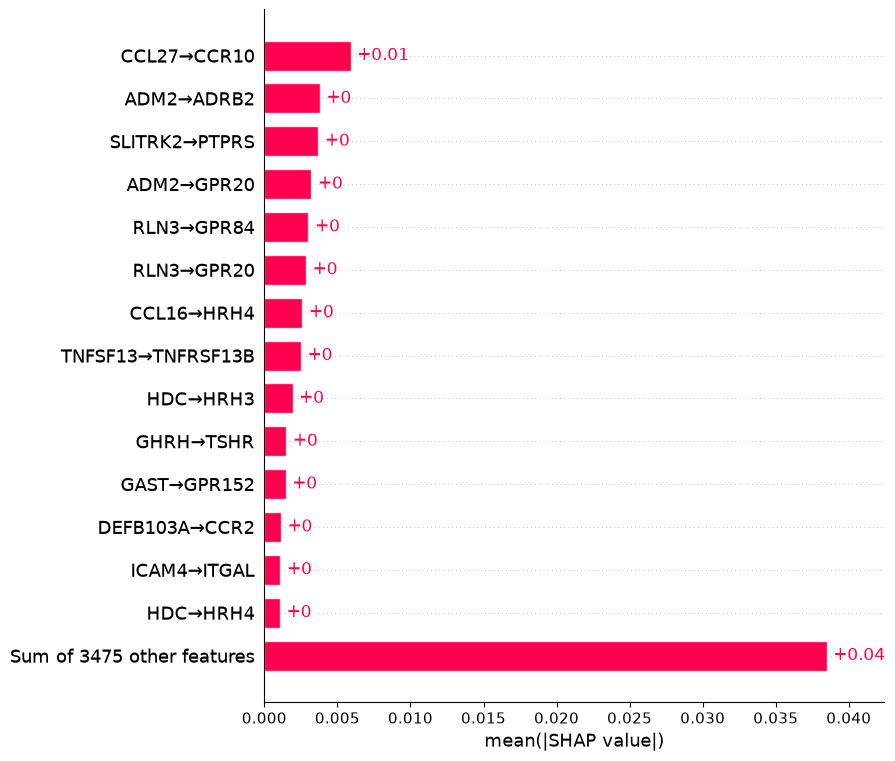

Program: 1


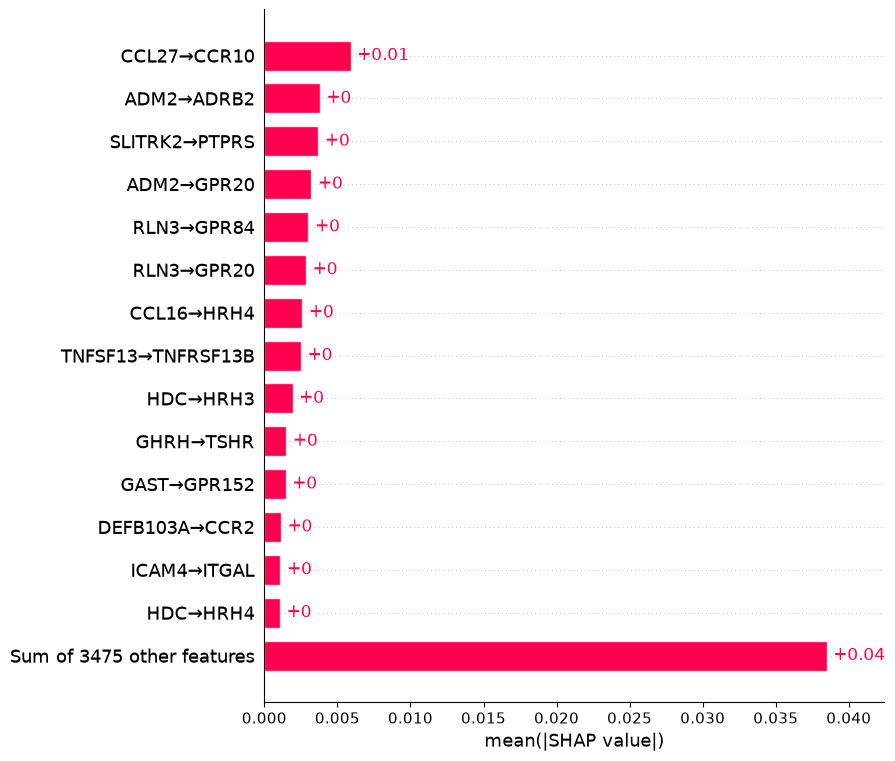

Program: 2


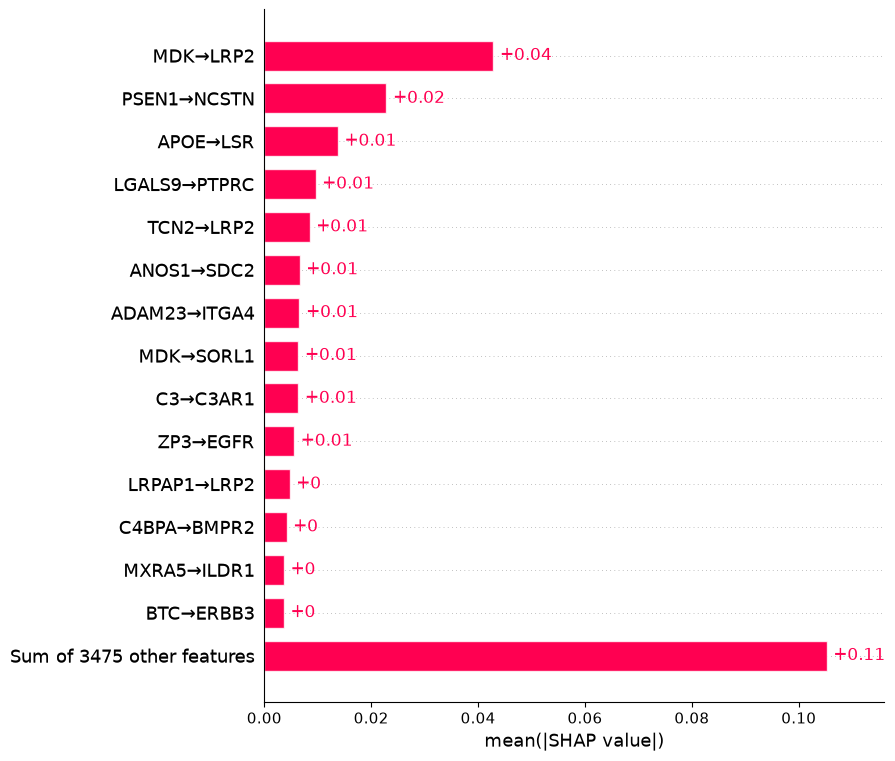

Program: 3


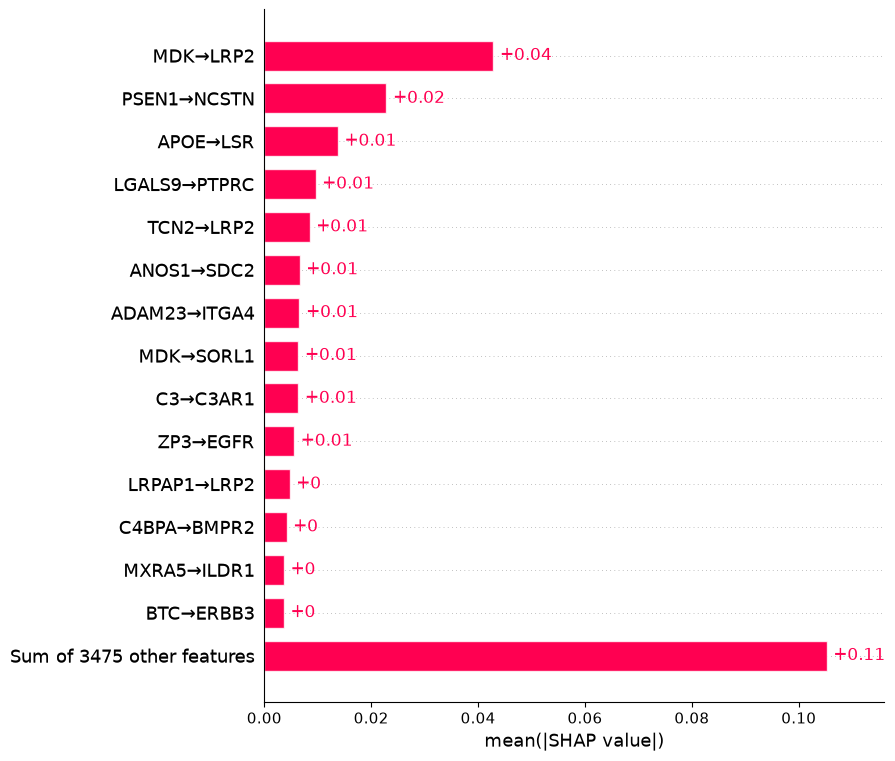

Program: 4


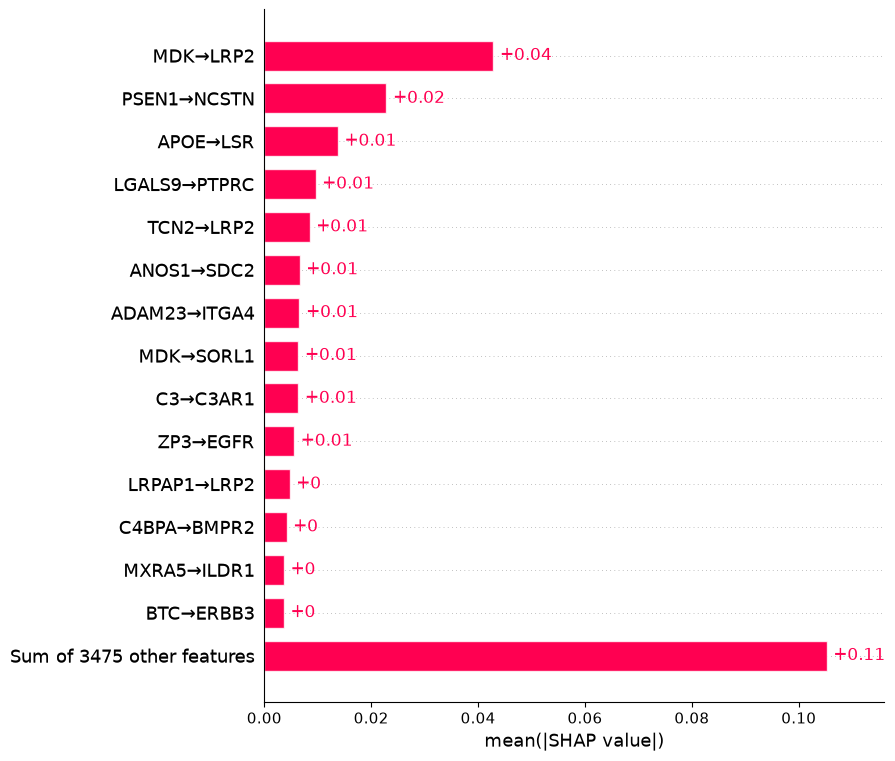

Program: 5


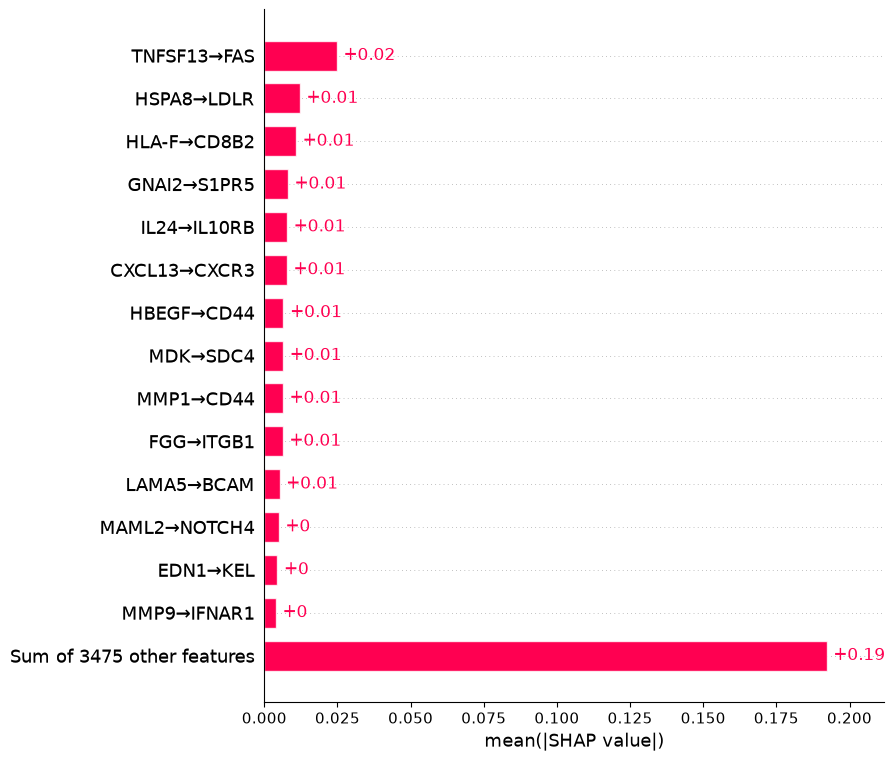

Program: 6


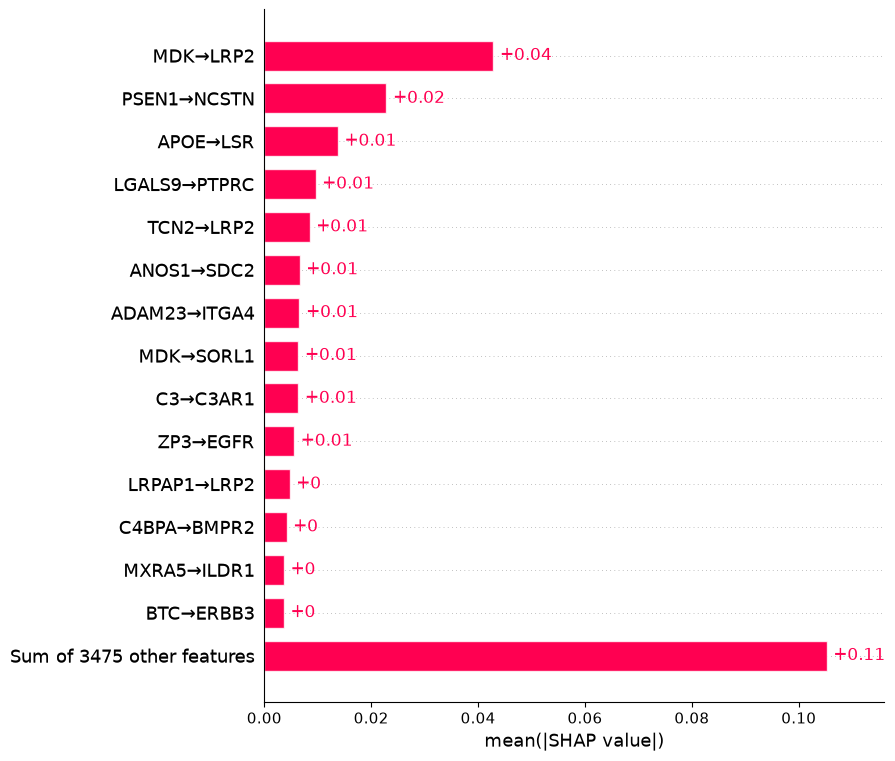

Program: 7


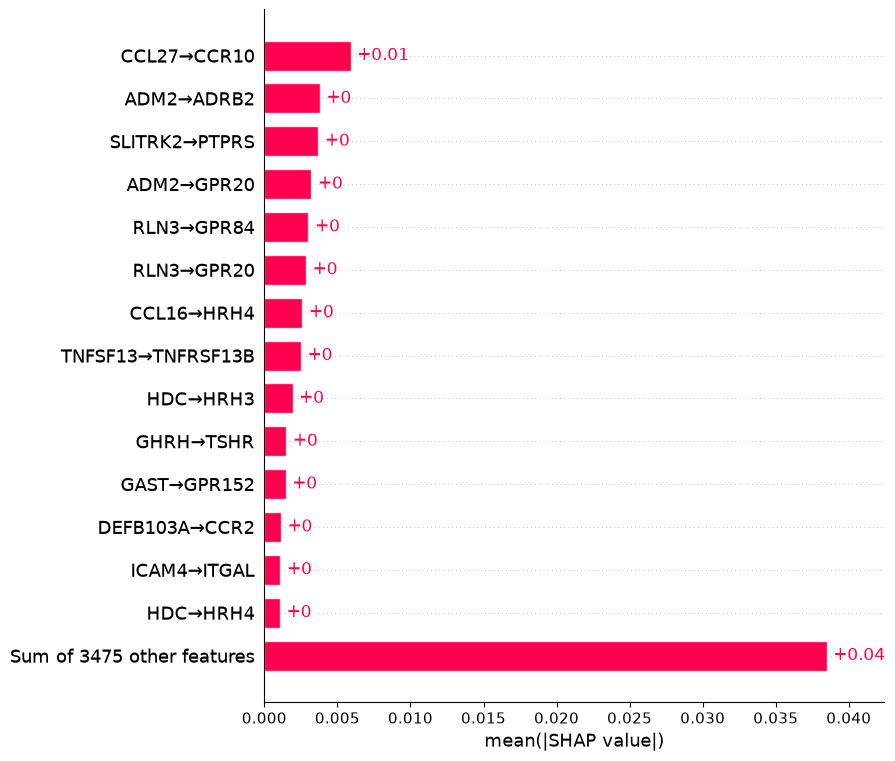

Program: 8


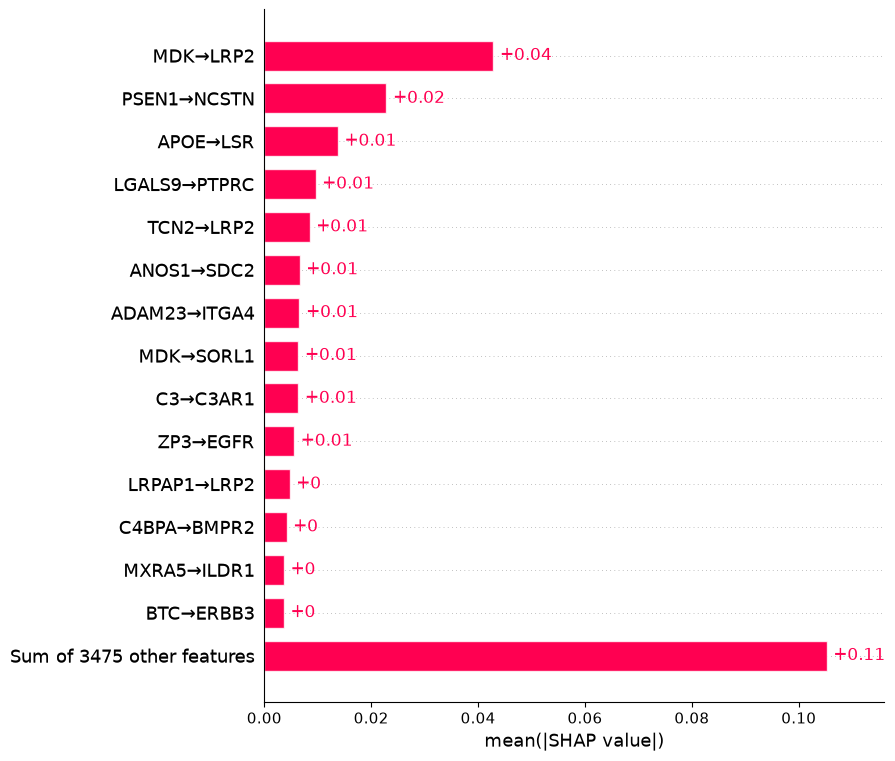

Program: 9


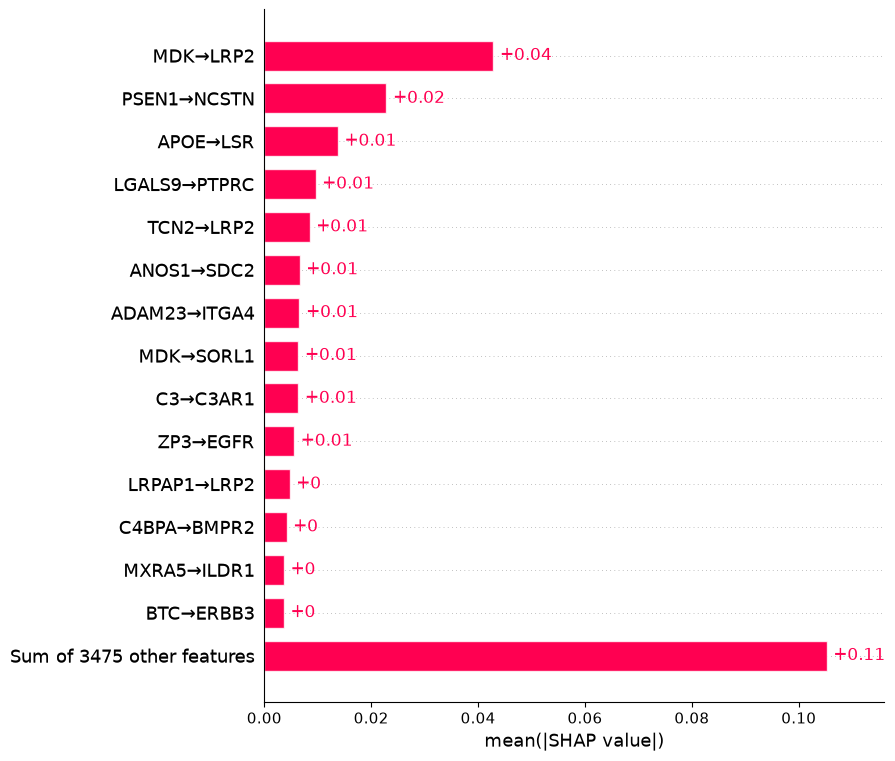

In [37]:
for program in shap_values.keys():

    print("Program:", program)

    shap.plots.bar(
        shap_values[program],
        max_display=15
    )